### Reto: "Predicción de Fallos en Equipos en Plantas Energéticas a 15 días vista"
Objetivo del Reto:
Evolucionar la solución para desarrollar un modelo analítico predictivo que permita anticipar fallos a 15 días vista en los equipos de la planta energética con una precisión mínima del 80% (accuracy ≥ 0.80) y por lo menos un 0.75 de f1.

Por un lado se quiere predecir las horas operativas que tendrá un equipo en los próximos 15 días, de cara a considerar su mantenimiento conforme a las horas recomendadas de revisión.
Por otro lado, se quiere evaluar si una máquina fallará en los próximos 15 días, con un 80% de fiabilidad.
Evalúa la robustés del modelo en el tiempo.

Para lograr esto, deberéis:

Mezclar y preprocesar los datos de los 3 datasets proporcionados, teniendo en cuenta la componente temporal.
Seleccionar variables relevantes y generar nuevas características si es necesario. Considera usar PCA para reducir dimensiones (conservando 95% de la varianza).
Construir y evaluar múltiples modelos predictivos, que inclyan forecasting y comparando su rendimiento.
Ajustar hiperparámetros y optimizar el modelo para alcanzar la precisión deseada.
Documentar los hallazgos y justificar la elección del mejor modelo.
Bonus 1: Encontrar patrones de fallos
Usa K-Means o DBSCAN para agrupar los equipos según sus condiciones operativas y comportamiento previo a los fallos.
Incluye las siguientes características para el clustering:
Promedio de temperatura y vibración por equipo.
Desviación estándar de temperatura y vibración.
Horas operativas acumuladas promedio.
Visualiza los clusters utilizando gráficos de dispersión o mapas de calor.
Interpreta los resultados: ¿Qué patrones emergen? ¿Hay grupos de equipos más propensos a fallar?
NOTAS:
Todas las soluciones en Python deben implementarse mediante funciones. Las funciones deben invocarse al final para ejecutar el proceso deseado.
Usar el kernel: Python 3.8 - AzureML (Python 3.10.11)
Estructura de carpetas:
Carpeta src para los jupyter notebooks y archivos de trabajo
Carpeta dist para exportar los jupyter notebooks a módulos. (Opcional).
Ejemplo:

.
└── repositorio/
    ├── dist/
    │   └── [módulos python]
    └── src/
        └── [archivos jupyter y python]

### Importando librerias y Dataframes

In [2]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

In [3]:
df_equipos = pd.read_csv('../DataExpert/etapa4/data/Caracteristicas_Equipos.csv')
df_ordenes = pd.read_csv('../DataExpert/etapa4/data/Historicos_Ordenes.csv')
df_condiciones = pd.read_csv('../DataExpert/etapa4/data/Registros_Condiciones.csv')

### Exploración de Dataframes

In [4]:
df_equipos.info()
df_ordenes.info()
df_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_Equipo                    500 non-null    int64 
 1   Tipo_Equipo                  500 non-null    object
 2   Fabricante                   500 non-null    object
 3   Modelo                       500 non-null    object
 4   Potencia_kW                  500 non-null    int64 
 5   Horas_Recomendadas_Revision  500 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 23.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Orden             31866 non-null  int64 
 1   ID_Equipo            31866 non-null  int64 
 2   Fecha                31866 non-null  object
 3   Tipo_Mantenimiento   31866 non-

In [5]:
df_equipos.head(6)

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision
0,1,Bomba,Fabricante_A,Modelo_8,432,657
1,2,Generador,Fabricante_B,Modelo_2,393,522
2,3,Motor,Fabricante_C,Modelo_7,398,885
3,4,Bomba,Fabricante_D,Modelo_4,121,668
4,5,Generador,Fabricante_C,Modelo_7,51,958
5,6,Generador,Fabricante_B,Modelo_7,79,968


In [6]:
df_ordenes.head(6)

,ID_Orden,ID_Equipo,Fecha,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion
0,1,382,2021-01-01,Correctivo,4331,16,Ubicacion_A
1,2,350,2021-01-01,Correctivo,2927,12,Ubicacion_A
2,3,302,2021-01-02,Correctivo,3863,6,Ubicacion_B
3,4,55,2021-01-02,Correctivo,1556,2,Ubicacion_D
4,5,89,2021-01-02,Correctivo,3680,17,Ubicacion_B
5,6,430,2021-01-02,Correctivo,1165,8,Ubicacion_D


In [38]:
df_condiciones.sample(10)

,ID_Registro,ID_Equipo,Fecha_condicion,Temperatura_C,Vibracion_mm_s,Horas_Operativas
455990,455991,30,2023-07-01,87.816836,2.906894,1786
641980,641981,222,2024-07-07,66.704579,0.000729,2678
661845,661846,393,2024-08-16,37.301897,6.798655,1269
63519,63520,428,2021-05-08,61.432092,3.086807,1693
301883,301884,119,2022-08-27,47.902732,9.132768,3127
294738,294739,31,2022-08-13,44.768314,3.267927,86
64913,64914,172,2021-05-10,60.611916,5.164574,95
285401,285402,203,2022-07-25,63.450796,7.992808,140
254925,254926,456,2022-05-25,78.573616,7.966467,1906
284866,284867,24,2022-07-24,59.293988,4.519197,420


## MANIPULACIÓN Y LIMPIEZA

 #### Comprobación existencia de valores vacios

In [8]:
vacios_equipos= df_equipos.isnull().sum()
vacios_ordenes= df_ordenes.isnull().sum()
vacios_condiciones= df_condiciones.isnull().sum()

In [9]:
print(vacios_equipos)
print(vacios_ordenes)
print(vacios_condiciones)



ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
dtype: int64
ID_Orden               0
ID_Equipo              0
Fecha                  0
Tipo_Mantenimiento     0
Costo_Mantenimiento    0
Duracion_Horas         0
Ubicacion              0
dtype: int64
ID_Registro         0
ID_Equipo           0
Fecha               0
Temperatura_C       0
Vibracion_mm_s      0
Horas_Operativas    0
dtype: int64


#### Comprobación duplicados

In [10]:
print(df_equipos.duplicated().sum())
print(df_condiciones.duplicated().sum())
print(df_ordenes.duplicated().sum())

0


0
0


In [11]:

# Definir una función para conservar el último valor del stream y aplicarlo a las columnas que se pueden categorizar
def conservar_ultimo(stream):
    return stream[-1]

columnas_a_modificar_equipos = ['Fabricante', 'Modelo']
df_equipos[columnas_a_modificar_equipos] = df_equipos[columnas_a_modificar_equipos].apply(lambda x: x.apply(conservar_ultimo))

columnas_a_modificar_ordenes = ['Ubicacion']
df_ordenes[columnas_a_modificar_ordenes] = df_ordenes[columnas_a_modificar_ordenes].apply(lambda x: x.apply(conservar_ultimo))


#### Categorizar y comprobar únicos

In [12]:
colum_recategorizar_equipos = ['Tipo_Equipo','Fabricante','Modelo']

df_equipos[colum_recategorizar_equipos] = df_equipos[colum_recategorizar_equipos].astype('category')
print(df_equipos['Tipo_Equipo'].unique())
print(df_equipos['Fabricante'].unique())
print(df_equipos['Modelo'].unique())


['Bomba', 'Generador', 'Motor', 'Compresor']
Categories (4, object): ['Bomba', 'Compresor', 'Generador', 'Motor']
['A', 'B', 'C', 'D']
Categories (4, object): ['A', 'B', 'C', 'D']
['8', '2', '7', '4', '6', '9', '5', '1', '0', '3']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


In [13]:
colum_recategorizar_ordenes = ['Tipo_Mantenimiento', 'Ubicacion']
df_ordenes[colum_recategorizar_ordenes] = df_ordenes[colum_recategorizar_ordenes].astype('category')
print(df_ordenes['Tipo_Mantenimiento'].unique())
print(df_ordenes['Ubicacion'].unique())

['Correctivo', 'Preventivo']
Categories (2, object): ['Correctivo', 'Preventivo']
['A', 'B', 'D', 'C']
Categories (4, object): ['A', 'B', 'C', 'D']


#### Cambio Dtype Fechas

In [14]:
df_ordenes['Fecha'] = pd.to_datetime(df_ordenes['Fecha'], errors='coerce')
df_ordenes.rename(columns={'Fecha': 'Fecha_mantenimiento'}, inplace=True)
df_ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Orden             31866 non-null  int64         
 1   ID_Equipo            31866 non-null  int64         
 2   Fecha_mantenimiento  31866 non-null  datetime64[ns]
 3   Tipo_Mantenimiento   31866 non-null  category      
 4   Costo_Mantenimiento  31866 non-null  int64         
 5   Duracion_Horas       31866 non-null  int64         
 6   Ubicacion            31866 non-null  category      
dtypes: category(2), datetime64[ns](1), int64(4)
memory usage: 1.3 MB


In [15]:
df_condiciones['Fecha'] = pd.to_datetime(df_condiciones['Fecha'], errors='coerce')
df_condiciones.rename(columns={'Fecha': 'Fecha_condicion'}, inplace=True)
df_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID_Registro       730500 non-null  int64         
 1   ID_Equipo         730500 non-null  int64         
 2   Fecha_condicion   730500 non-null  datetime64[ns]
 3   Temperatura_C     730500 non-null  float64       
 4   Vibracion_mm_s    730500 non-null  float64       
 5   Horas_Operativas  730500 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 33.4 MB


#### Cálculo Horas entre mantenimiento

In [16]:
df_dias_entre_mto = df_ordenes.groupby('ID_Equipo')['Fecha_mantenimiento'].diff().reset_index(name='Dias_entre_ordenes')
df_dias_entre_mto['ID_Equipo'] = df_ordenes['ID_Equipo']
df_dias_entre_mto= df_dias_entre_mto[['ID_Equipo', 'Dias_entre_ordenes']]
df_dias_entre_mto.sample(10)


,ID_Equipo,Dias_entre_ordenes
29540,9,24 days
23830,58,32 days
29527,31,19 days
19842,401,15 days
29560,419,28 days
2770,410,31 days
21359,260,4 days
10908,229,1 days
9170,283,27 days
30284,7,37 days


In [63]:
df_dias_entre_mto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31866 entries, 0 to 31865
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   ID_Equipo           31866 non-null  int64          
 1   Dias_entre_ordenes  31366 non-null  timedelta64[ns]
dtypes: int64(1), timedelta64[ns](1)
memory usage: 498.0 KB


In [64]:
df_media_dias_mto= df_dias_entre_mto.groupby('ID_Equipo')['Dias_entre_ordenes'].mean().reset_index(name= 'Media dias orden')
df_media_dias_mto.info()
df_media_dias_mto.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   ID_Equipo         500 non-null    int64          
 1   Media dias orden  500 non-null    timedelta64[ns]
dtypes: int64(1), timedelta64[ns](1)
memory usage: 7.9 KB


,ID_Equipo,Media dias orden
0,1,21 days 21:00:00
1,2,16 days 22:00:00
2,3,25 days 22:13:20
3,4,21 days 23:15:00
4,5,31 days 12:16:00
5,6,30 days 13:33:54.782608695
6,7,33 days 04:00:00
7,8,22 days 14:28:34.285714285
8,9,18 days 23:02:24
9,10,17 days 16:48:00


#### Temperatura media por equipo

In [18]:
df_cond_temp_media= df_condiciones.groupby('ID_Equipo')['Temperatura_C'].mean().reset_index(name='Temp_Media').astype('int64')
df_cond_temp_media.head()

,ID_Equipo,Temp_Media
0,1,60
1,2,60
2,3,59
3,4,60
4,5,60


#### Union de dataframes

In [19]:
df_ordenes_media=pd.merge(df_ordenes, df_media_dias_mto, on='ID_Equipo')
df_ordenes_media_equipos= pd.merge(df_ordenes_media, df_equipos, on= 'ID_Equipo')

df_ordenes_media_equipos['Media dias orden'] = pd.to_timedelta(df_ordenes_media_equipos['Media dias orden'])
df_ordenes_media_equipos['Tiempo medio entre orden en horas'] = df_ordenes_media_equipos['Media dias orden'].dt.total_seconds() / 3600
df_ordenes_media_equipos['Tiempo medio entre orden en horas']= df_ordenes_media_equipos['Tiempo medio entre orden en horas'].astype('int32')
#df_completo= pd.merge(df_ordenes_media_equipos, df_condiciones, on= 'ID_Equipo')
df_ordenes_media_equipos.sample(10)
#df_ordenes_media_equipos.info()

,ID_Orden,ID_Equipo,Fecha_mantenimiento,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Media dias orden,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tiempo medio entre orden en horas
20,21,257,2021-01-05,Correctivo,4980,18,D,23 days 20:27:32.459016393,Bomba,A,7,57,873,572
29767,29768,163,2024-09-26,Preventivo,391,1,A,29 days 06:00:00,Compresor,D,7,304,877,702
19656,19657,51,2023-06-23,Preventivo,357,1,C,17 days 14:31:06.666666666,Bomba,C,4,351,500,422
21183,21184,65,2023-09-01,Preventivo,964,1,D,23 days 08:39:20.655737705,Bomba,B,5,468,762,560
3866,3867,71,2021-07-08,Preventivo,248,1,C,26 days 08:53:20,Generador,B,2,436,974,632
5177,5178,36,2021-09-05,Preventivo,207,2,B,28 days 14:12:14.693877551,Bomba,B,3,92,986,686
30948,30949,311,2024-11-20,Preventivo,404,1,A,24 days 02:26:26.440677966,Bomba,C,1,326,750,578
9650,9651,73,2022-03-29,Preventivo,349,1,D,26 days 01:46:40,Compresor,C,5,457,863,625
6953,6954,1,2021-11-25,Preventivo,428,1,A,21 days 21:00:00,Bomba,A,8,432,657,525
27355,27356,65,2024-06-08,Preventivo,685,1,D,23 days 08:39:20.655737705,Bomba,B,5,468,762,560


#### Eliminar Columnas

In [20]:
df_ordenes_media_equipos= df_ordenes_media_equipos.drop(columns= ['Media dias orden'])
df_ordenes_media_equipos.head()

,ID_Orden,ID_Equipo,Fecha_mantenimiento,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Tiempo medio entre orden en horas
0,1,382,2021-01-01,Correctivo,4331,16,A,Bomba,A,0,281,634,506
1,2,350,2021-01-01,Correctivo,2927,12,A,Generador,A,9,127,608,505
2,3,302,2021-01-02,Correctivo,3863,6,B,Generador,C,9,331,701,528
3,4,55,2021-01-02,Correctivo,1556,2,D,Compresor,B,9,71,660,486
4,5,89,2021-01-02,Correctivo,3680,17,B,Compresor,D,3,281,750,594


## Predicción horas operativas que tendrá un equipo en los próximos 15 días

In [21]:
#! pip install skforecast
#! pip install shap

In [22]:
import shap
import skforecast
from skforecast.utils import load_forecaster
from skforecast.utils import save_forecaster
from skforecast.preprocessing import RollingFeatures
from skforecast.model_selection import backtesting_forecaster
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import TimeSeriesFold
from skforecast.direct import ForecasterDirect
from skforecast.recursive import ForecasterRecursive
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

In [23]:
df_condiciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730500 entries, 0 to 730499
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ID_Registro       730500 non-null  int64         
 1   ID_Equipo         730500 non-null  int64         
 2   Fecha_condicion   730500 non-null  datetime64[ns]
 3   Temperatura_C     730500 non-null  float64       
 4   Vibracion_mm_s    730500 non-null  float64       
 5   Horas_Operativas  730500 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 33.4 MB


#### Establecer como indice "Fecha_condicion" 

In [65]:
df_condiciones.head(10)

,ID_Registro,ID_Equipo,Fecha_condicion,Temperatura_C,Vibracion_mm_s,Horas_Operativas
0,1,1,2021-01-01,36.587104,4.430381,579
1,2,106,2021-01-01,53.268051,0.534711,577
2,3,446,2021-01-01,47.176472,7.116958,263
3,4,107,2021-01-01,76.404597,2.696906,491
4,5,108,2021-01-01,50.729327,6.996772,589
5,6,445,2021-01-01,62.576903,7.935557,519
6,7,109,2021-01-01,32.386760,7.673691,651
7,8,110,2021-01-01,93.043315,2.793286,726
8,9,444,2021-01-01,40.860262,5.329370,222
9,10,111,2021-01-01,67.170800,4.797625,172


In [61]:

# Agrupar por  'Fecha_condicion' y 'ID_Equipo' y aplicar funciones de agregación
df_condiciones_group= df_condiciones.groupby(['Fecha_condicion', 'ID_Equipo']).agg({'Temperatura_C': 'mean','Vibracion_mm_s': 'mean','Horas_Operativas': 'first'})

df_condiciones_group.sample(10)


,,Temperatura_C,Vibracion_mm_s,Horas_Operativas
Fecha_condicion,ID_Equipo,,,
2024-08-02,437,71.963498,8.512997,796
2021-04-28,394,70.233561,4.507384,1291
2023-12-13,48,20.171265,5.912719,2935
2021-12-01,351,65.510883,4.789149,870
2023-08-05,190,68.588350,1.703069,243
2021-05-24,320,55.741456,9.859309,1284
2024-01-29,77,22.938227,5.540594,594
2022-11-19,146,49.974170,2.799395,120
2021-07-17,123,25.814027,6.293415,416


In [66]:
df_condiciones_group.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 730500 entries, (Timestamp('2021-01-01 00:00:00'), 1) to (Timestamp('2024-12-31 00:00:00'), 500)
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Temperatura_C     730500 non-null  float64
 1   Vibracion_mm_s    730500 non-null  float64
 2   Horas_Operativas  730500 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 19.5 MB


In [62]:
#Comprobación que no hay valores vaciós
print('Número de filas con valores faltantes:', df_condiciones_group.isnull().any(axis=1).mean())

Número de filas con valores faltantes: 0.0


In [60]:
#Fecha inicio final indice 
fecha_inicio= df_condiciones_group['Fecha_condicion'].min()
fecha_fin= df_condiciones_group['Fecha_condicion'].max()
print(fecha_inicio)
print(fecha_fin)


2021-01-01 00:00:00
2024-12-31 00:00:00


Fechas train : (Timestamp('2021-01-01 00:00:00'), 1) --- (Timestamp('2024-11-11 00:00:00'), 500)  (n=705500)
Fechas test  : (Timestamp('2024-11-12 00:00:00'), 1) --- (Timestamp('2024-12-31 00:00:00'), 500)  (n=25000)


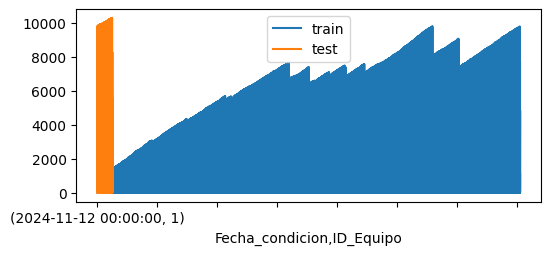

In [71]:
# Separación de datos para train-test

steps = 25000
datos_train = df_condiciones_group[:-steps]
datos_test = df_condiciones_group[-steps:]
print(f"Fechas train : {datos_train.index.min()} --- {datos_train.index.max()}  (n={len(datos_train)})")
print(f"Fechas test  : {datos_test.index.min()} --- {datos_test.index.max()}  (n={len(datos_test)})")

fig, ax = plt.subplots(figsize=(6, 2.5))
datos_train['Horas_Operativas'].plot(ax=ax, label='train')
datos_test['Horas_Operativas'].plot(ax=ax, label='test')
ax.legend();